In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/breast-cancer-wisconsin-data/data.csv


# import libraries 

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report 
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


# load data

In [3]:
data=pd.read_csv('/kaggle/input/breast-cancer-wisconsin-data/data.csv')
data

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


# explore data

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


In [6]:
data.shape

(569, 33)

In [7]:
n_data=data.isnull().sum()
n_data[n_data>0]

Unnamed: 32    569
dtype: int64

<Axes: >

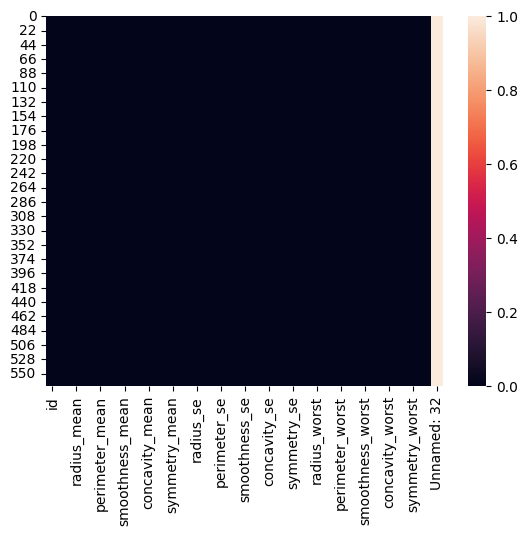

In [8]:
sns.heatmap(data.isnull())

In [9]:
data.duplicated().sum()

0

# EDA 

In [10]:
data

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [11]:
data.diagnosis.value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

<Axes: xlabel='diagnosis', ylabel='count'>

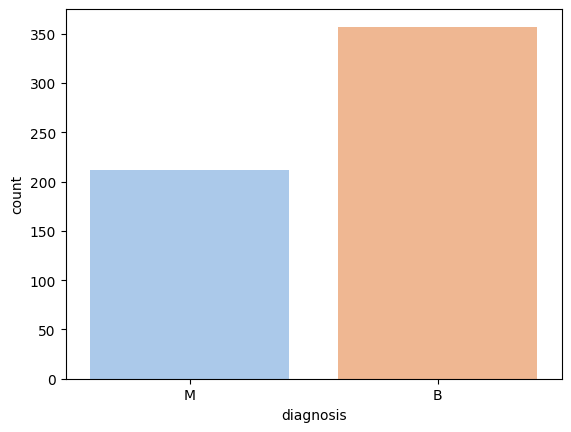

In [12]:
sns.countplot(x=data['diagnosis'],palette='pastel')

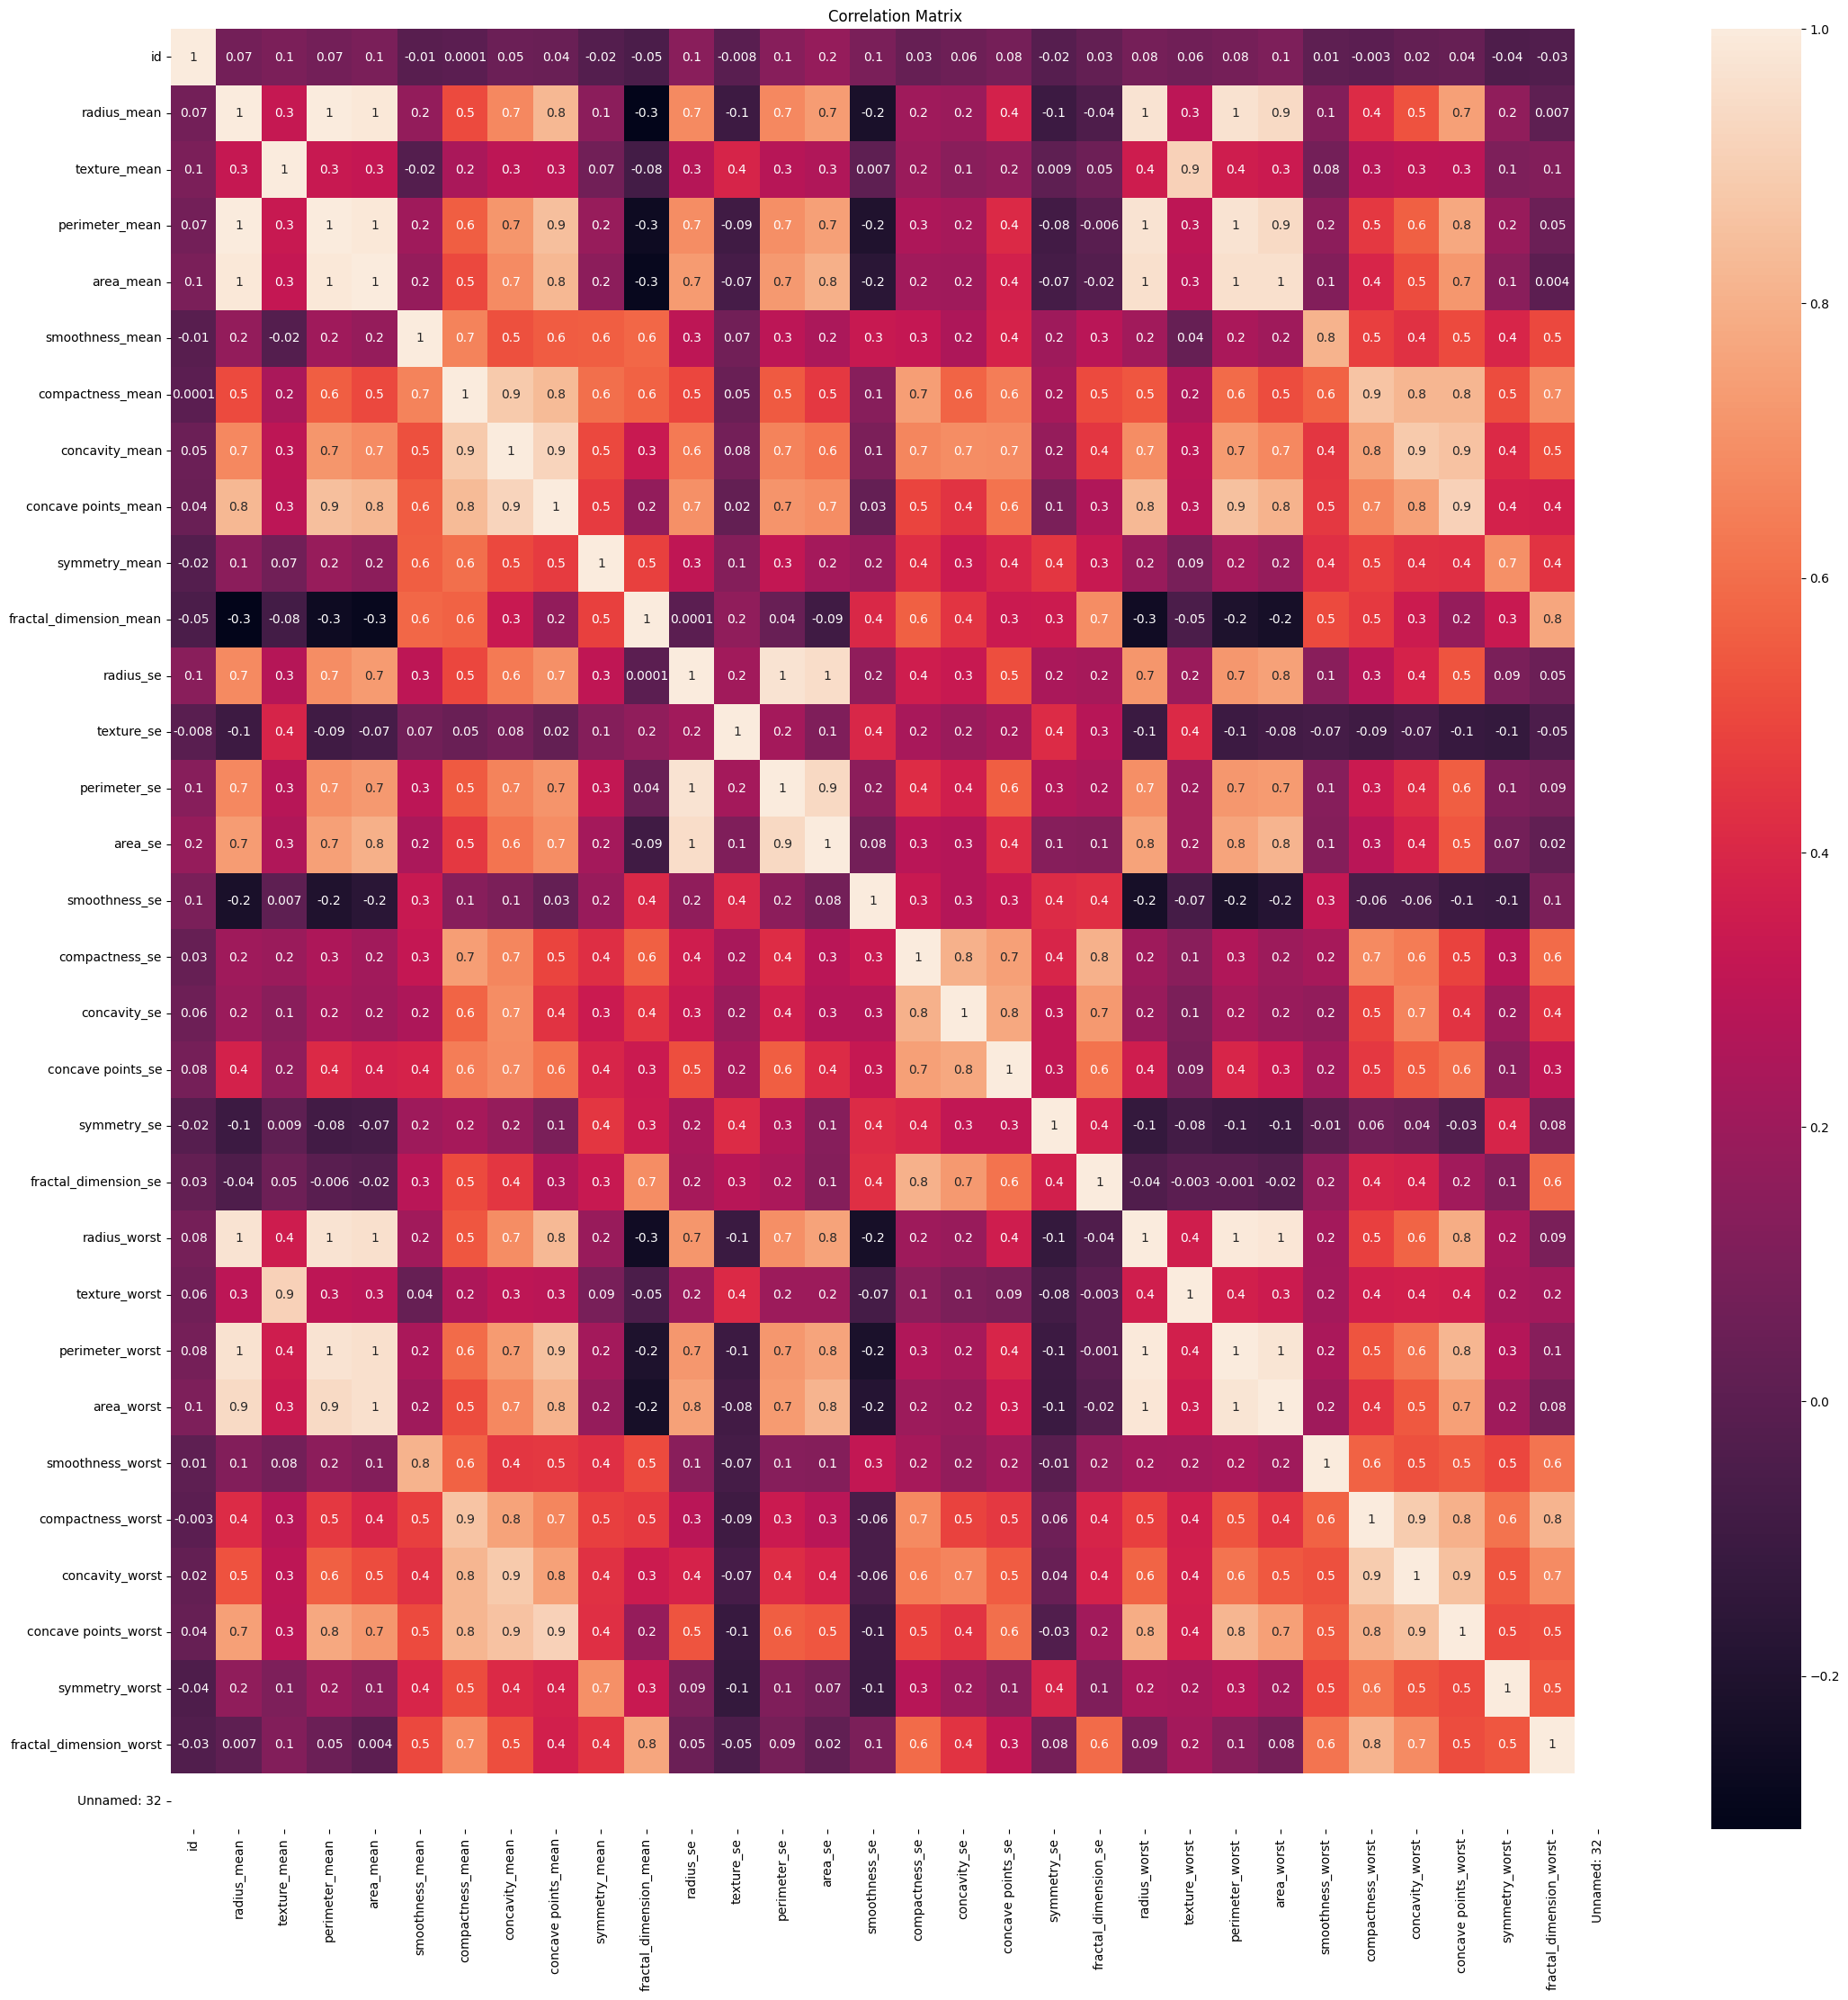

In [13]:
num_cols = data.select_dtypes(include='number').columns
plt.figure(figsize=(26, 26))

corr_matrix = data[num_cols].corr()
corr_matrix

sns.heatmap(corr_matrix,annot=True,fmt=".1g")
plt.title('Correlation Matrix')
plt.show()

# data cleaning

In [14]:
data.drop(['id','Unnamed: 32'],axis=1,inplace=True)


In [15]:
data.diagnosis.replace({'M':'1','B':'0'},inplace=True)

/tmp/ipykernel_19/3084097893.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data.diagnosis.replace({'M':'1','B':'0'},inplace=True)


<Axes: ylabel='count'>

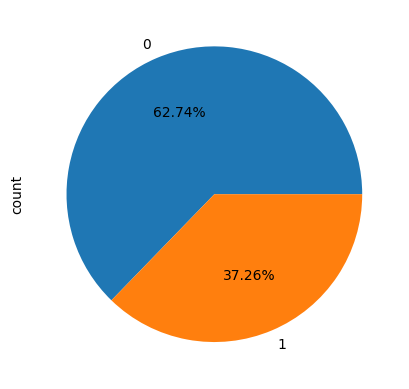

In [16]:
data.diagnosis.value_counts().plot.pie(autopct='%.2f%%')

In [17]:
data.isna().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

# handel outlire 

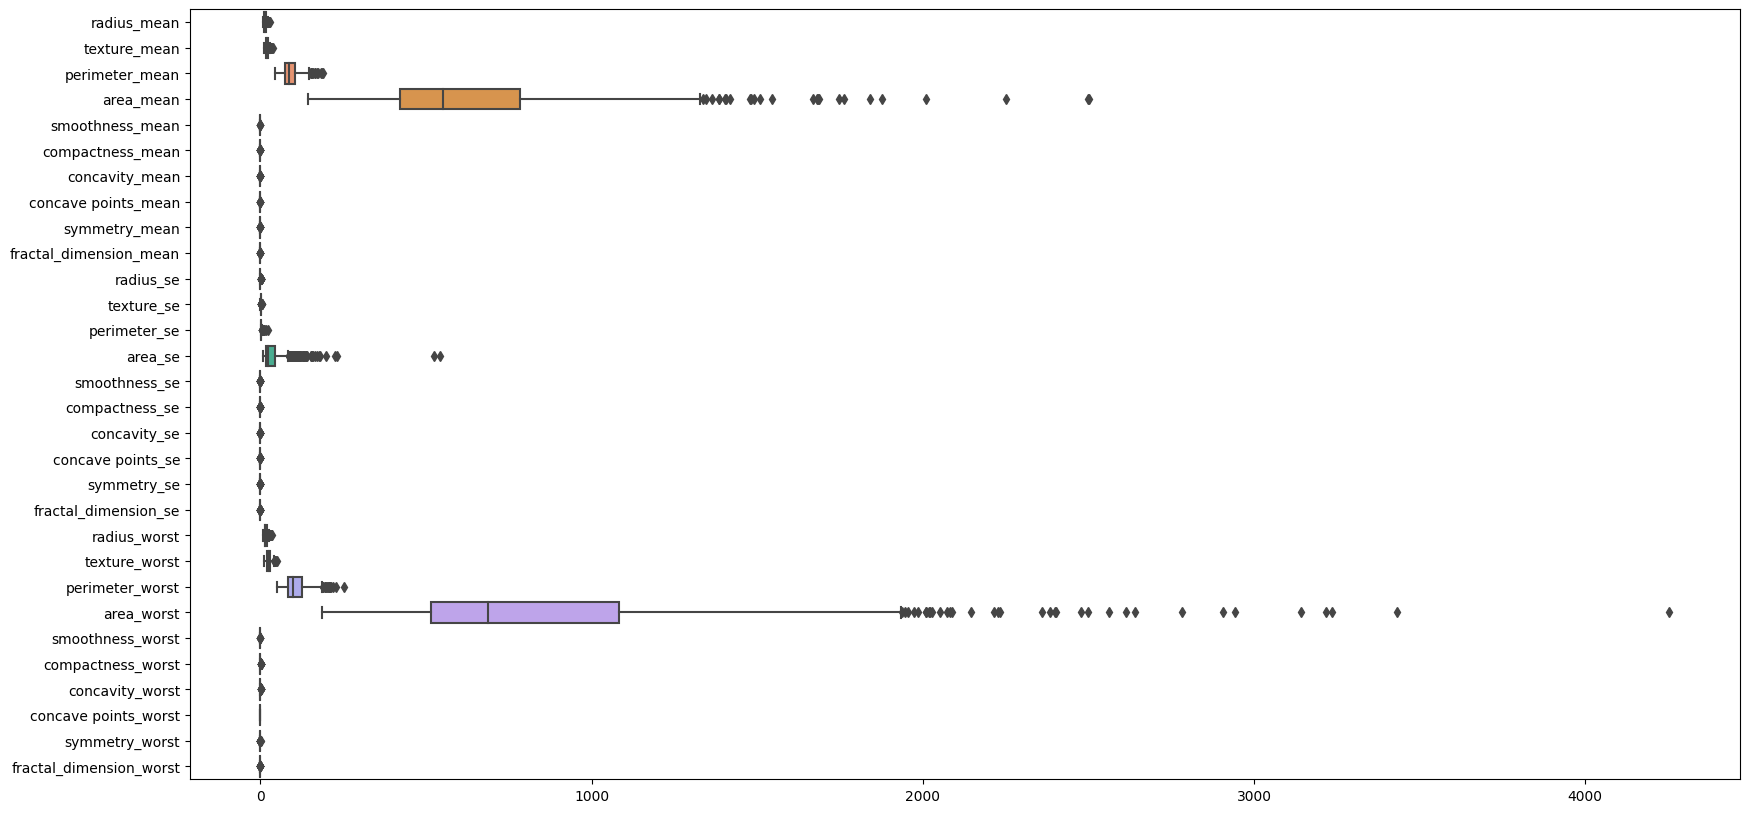

In [18]:
plt.figure(figsize=(20, 10))
sns.boxplot(data=data, orient="h")
plt.show()

In [19]:
def handle_outliers(data, columns):
    for column in columns:
        if column in data.columns:
            q1 = data[column].quantile(0.25)
            q3 = data[column].quantile(0.75)
            iqr = q3 - q1
            low_b = q1 - 1.5 * iqr
            high_b = q3 + 1.5 * iqr
            a = data[column] < low_b
            b = data[column] > high_b
            data[column] = np.where(a, low_b, np.where(b, high_b, data[column]))
    return data
num_col = data.select_dtypes(include='number').columns
for col in num_col:
    data = handle_outliers(data, [col])

# split data feature & target 

In [20]:
x=data.drop('diagnosis',axis=1)
y=data.diagnosis

# scale data 

In [21]:
scale = StandardScaler()
xscale = scale.fit_transform(x)

# split train & test 

In [22]:
x_train,x_test,y_train,y_test=train_test_split(xscale,y,test_size=0.2,random_state=42)

# build model 

In [23]:
log_reg=LogisticRegression()
rf_clf=RandomForestClassifier()
svc=SVC()

In [24]:
def all(model):
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    accuracy_test=accuracy_score(y_pred,y_test)*100
    accuracy_train=model.score(x_train,y_train)*100
    print('accuracy after train model :',accuracy_train)
    print('accuracy after test  model :',accuracy_test)

In [25]:
all(log_reg)

accuracy after train model : 98.68131868131869
accuracy after test  model : 98.24561403508771


In [26]:
all(rf_clf)

accuracy after train model : 100.0
accuracy after test  model : 96.49122807017544


In [27]:
all(svc)

accuracy after train model : 98.9010989010989
accuracy after test  model : 97.36842105263158


# evaluate model 

In [28]:
def cm(model):
    y_pred=model.predict(x_test)

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model.classes_)
    disp.plot(cmap='Greens')
    plt.title('Confusion Matrix')
    plt.show()

<Figure size 800x600 with 0 Axes>

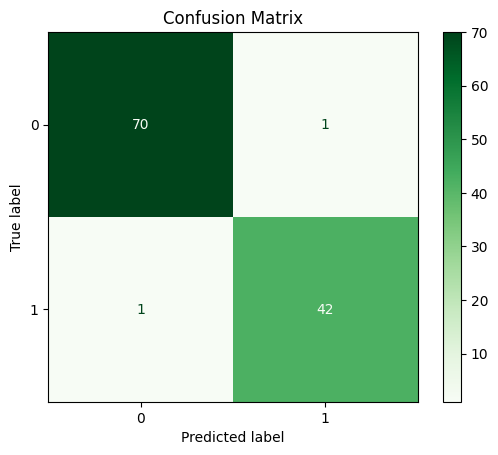

In [29]:
cm(log_reg)

In [30]:
def class_report(model):
    y_pred=model.predict(x_test)
    report = classification_report(y_test, y_pred, target_names=['Benign', 'Malignant'])
    print("Classification Report:\n", report)

In [31]:
class_report(log_reg)

Classification Report:
               precision    recall  f1-score   support

      Benign       0.99      0.99      0.99        71
   Malignant       0.98      0.98      0.98        43

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [ ]:
import numpy as np
import ipywidgets as widgets
from IPython.display import display
from sklearn.datasets import load_breast_cancer

# ---------- Load dataset for feature names ----------
data = load_breast_cancer()
feature_names = data.feature_names

# ---------- Create input widgets dynamically ----------
feature_inputs = {}
for feature in feature_names:
    feature_inputs[feature] = widgets.FloatText(
        description=feature[:15], layout=widgets.Layout(width="350px")
    )

# ---------- Header ----------
header = widgets.HTML("<h2 style='color:green'>🏥 Breast Cancer Prediction Tool</h2>")
subheader = widgets.HTML("<i>Fill the features below to predict cancer risk:</i>")

# ---------- Scrollable input area ----------
inputs_box = widgets.VBox(list(feature_inputs.values()))
scrollable_box = widgets.Box([inputs_box],
                             layout=widgets.Layout(
                                 height='500px',
                                 overflow_y='auto',
                                 border='1px solid gray',
                                 padding='10px'
                             ))

accordion = widgets.Accordion(children=[scrollable_box])
accordion.set_title(0, "Patient Feature Inputs")

# ---------- Predict button and output ----------
submit_button = widgets.Button(description="Predict Cancer", button_style="success", layout=widgets.Layout(width='200px'))
output = widgets.Output()

# ---------- Detect model classes automatically ----------
# Assign benign/malignant based on first class alphabetically if string
# or 0/1 if numeric
classes = lr_model.classes_
if classes.dtype.type is np.str_:
    # Strings like ['B','M']
    benign_label = min(classes)
    malignant_label = max(classes)
else:
    # Numeric like [0,1]
    benign_label = min(classes)
    malignant_label = max(classes)

# ---------- Prediction function ----------
def on_button_click(b):
    with output:
        output.clear_output()
        # Collect input values
        input_data = [feature_inputs[f].value for f in feature_names]
        input_array = np.array(input_data).reshape(1, -1)
        
        # Predict
        prediction = lr_model.predict(input_array)[0]
        # Get probability safely
        class_index = np.where(classes == prediction)[0][0]
        probability = lr_model.predict_proba(input_array)[0][class_index] * 100
        
        # Display result
        if prediction == benign_label:
            display(widgets.HTML(f"<p style='color:green;font-size:18px'>✅ Result: Benign (Non-cancerous) | Confidence: {probability:.2f}%</p>"))
        elif prediction == malignant_label:
            display(widgets.HTML(f"<p style='color:red;font-size:18px'>⚠️ Result: Malignant (Cancerous) | Confidence: {probability:.2f}%</p>"))
        else:
            display(widgets.HTML(f"<p style='color:orange;font-size:18px'>❓ Unknown prediction: {prediction}</p>"))

submit_button.on_click(on_button_click)

# ---------- Optional: File upload for batch predictions ----------
upload = widgets.FileUpload(accept='.csv', multiple=False)
upload_output = widgets.Output()

def handle_upload(change):
    with upload_output:
        upload_output.clear_output()
        for filename, file_info in upload.value.items():
            import pandas as pd
            from io import BytesIO
            df = pd.read_csv(BytesIO(file_info['content']))
            print("Preview of uploaded CSV:")
            display(df.head())
            
            # Run predictions on uploaded data
            try:
                predictions = lr_model.predict(df.values)
                probs = lr_model.predict_proba(df.values)
                results = []
                for i, pred in enumerate(predictions):
                    class_idx = np.where(classes == pred)[0][0]
                    conf = probs[i][class_idx] * 100
                    results.append((pred, conf))
                print("\nPredictions for uploaded data:")
                for i, (pred, conf) in enumerate(results):
                    label = "Benign" if pred == benign_label else "Malignant"
                    print(f"Row {i+1}: {label} | Confidence: {conf:.2f}%")
            except Exception as e:
                print("Error predicting uploaded data:", e)

upload.observe(handle_upload, names='value')

# ---------- Display all widgets ----------
app_layout = widgets.VBox([
    header, subheader,
    accordion,
    widgets.HBox([submit_button, upload]),
    output,
    upload_output
])

display(app_layout)
